# Scientific plotting for publication with OmicVerse

In this tutorial, we focus on a practical question: **how to make biologically accurate, visually consistent, and publication-ready figures when using `omicverse`**.

This is not only an API tutorial. We will explain **what to do**, **why to do it**, and **which mistakes to avoid** when generating figures for manuscripts, preprints, and reports.

The core principles are:

- figures should communicate biology before decoration
- the same biological category should keep the same color across figures
- panel size, font, resolution, and export format should be standardized early
- continuous and categorical variables should use different color logic
- final figures should be exported in both raster and vector formats whenever possible

In [15]:
import omicverse as ov
import scanpy as sc
import squidpy as sq
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Optional: use a processed AnnData object from your own analysis.
# adata = ...

# OmicVerse provides convenient styling helpers.
ov.plot_set(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] Tesla P100-PCIE-16GB
      Memory: 15.9 GB | Compute: 6.0
✅ plot_set complete.



## 1. Start from a reproducible visual standard

The first step in scientific plotting is **not plotting**. It is defining a reproducible visual baseline.

Why this matters:

- If you tune font size and panel size manually for every figure, the entire manuscript becomes inconsistent.
- If you save one figure at low resolution and another at high resolution, journal assembly becomes painful.
- If you decide colors only at the end, you usually break consistency across embeddings, heatmaps, and spatial panels.

A good default for compact manuscript figures is:

- single panel: `figsize=(4, 4)` or `figsize=(3, 3)`
- dense matrix or large embedding: `figsize=(8, 8)`
- final export: `dpi=300`
- crop white margins: `bbox_inches='tight'`
- save both `png` and `svg`

In [2]:
adata=ov.datasets.pbmc8k()

🩸 Downloading PBMC 8k dataset
Using Stanford mirror for pbmc8k
🔍 Downloading data to ./data/pbmc8k.h5ad...



Downloading: |          | 41.4M/0.00 [00:01<00:00, 25.9MB/s]

✅ Download completed
 Loading data from ./data/pbmc8k.h5ad
✅ Successfully loaded: 7750 cells × 20939 genes


In [19]:
def set_publication_style(fontsize=12):
    plt.rcParams['figure.dpi'] = 80
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['font.size'] = fontsize
    plt.rcParams['axes.labelsize'] = fontsize
    plt.rcParams['axes.titlesize'] = fontsize + 1
    plt.rcParams['xtick.labelsize'] = fontsize - 1
    plt.rcParams['ytick.labelsize'] = fontsize - 1
    plt.rcParams['legend.fontsize'] = fontsize - 1
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42


def save_figure_pair(stem):
    plt.savefig(f'{stem}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{stem}.svg')
    #plt.savefig(f'{stem}.pdf')


set_publication_style(fontsize=13)

## 2. Separate categorical color design from continuous color design

A common mistake is to use the same color logic for all figures.

This is incorrect because:

- **categorical annotations** such as cell types, clusters, niches, and samples require **stable named colors**
- **continuous values** such as scores, abundance, logFC, or expression require **ordered colormaps**

Purpose of this step:

- make the reader recognize the same biology instantly across multiple figures
- prevent visual misinterpretation caused by arbitrary remapping
- improve comparability between panels

Recommended rules:

- for cell types or clusters: build a dictionary once and reuse it everywhere
- for abundance-like values: start with `Reds`
- for signed effects such as enrichment or log fold change: start with `RdBu_r`

In [5]:
# Example: stable categorical palette.
# Replace 'cell_type' with your own annotation column.

if 'cell_type' in getattr(adata, 'obs', {}):
    categories = list(adata.obs['cell_type'].astype('category').cat.categories)
    palette = ov.pl.sc_color[8:] + ov.pl.red_color + ov.pl.orange_color + ov.pl.sc_color
    color_dict = {k: palette[i] for i, k in enumerate(categories)}
else:
    color_dict = {
        'T cell': '#279AD7',
        'B cell': '#F0A202',
        'Myeloid': '#E45756',
        'Stromal': '#54A24B',
    }

# Example: continuous colormap choices.
seq_cmap = 'Reds'      # abundance, score, density, expression intensity
signed_cmap = 'RdBu_r' # up/down, positive/negative, centered contrasts

## 3. Make embeddings readable before making them beautiful

UMAP, MDE, t-SNE, and spatial embeddings are often the first figures people see. Their purpose is usually **overview and orientation**, not decoration.

What this step should achieve:

- show the major biological structure clearly
- preserve category identity with stable colors
- remove unnecessary visual clutter

Good practice:

- use a compact square panel
- keep point size moderate
- remove oversized legends inside dense panels
- avoid changing palette order across figures
- use the same `basis` and annotation names consistently throughout the tutorial or manuscript

In [6]:
adata

AnnData object with n_obs × n_vars = 7750 × 20939
    obs: 'kit', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'predicted_celltype', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    obsm: 'UMAP', 'X_pca', 'X_umap'

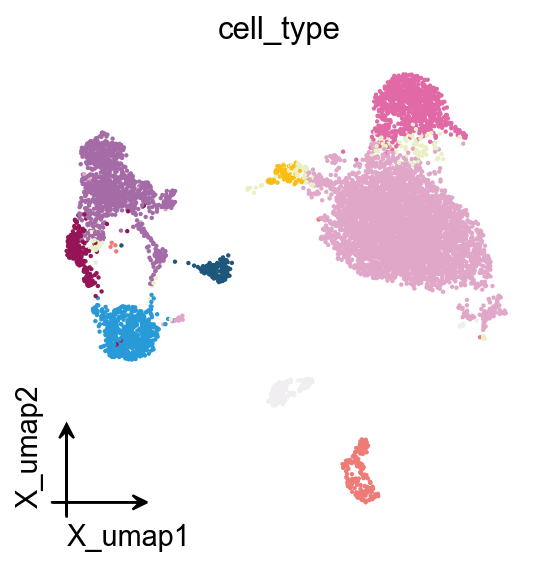

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


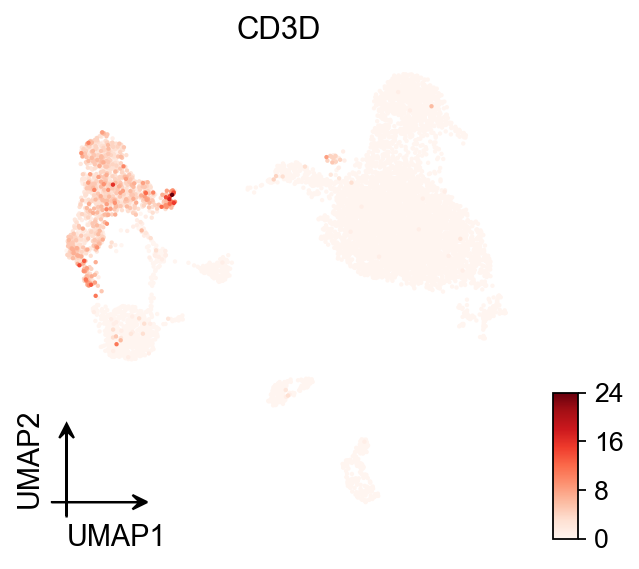

In [26]:
# Categorical embedding
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='cell_type',
    #palette=color_dict,
    frameon='small',
    legend_loc=None,
    show=False,
    ax=ax,
)
save_figure_pair('figures/plotting/embedding_celltype')
plt.show()

# Continuous embedding
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.umap(
    adata,
    color='CD3D',
    cmap='Reds',
    frameon='small',
    show=False,
    ax=ax,
)
save_figure_pair('figures/plotting/embedding_module_score')
plt.show()

## 4. Use dotplots and violins to answer specific biological questions

Embeddings are useful for overview, but they are weak for exact comparison. When you need to compare **marker intensity**, **signature activity**, or **group differences**, use summary plots.

Why this step matters:

- dotplots compress many genes and groups into a readable panel
- violin plots expose distribution shape instead of only mean signal
- these plots provide stronger support for biological interpretation than embeddings alone

The goal is not to show more genes. The goal is to show the **right genes** with a **clear group order**.

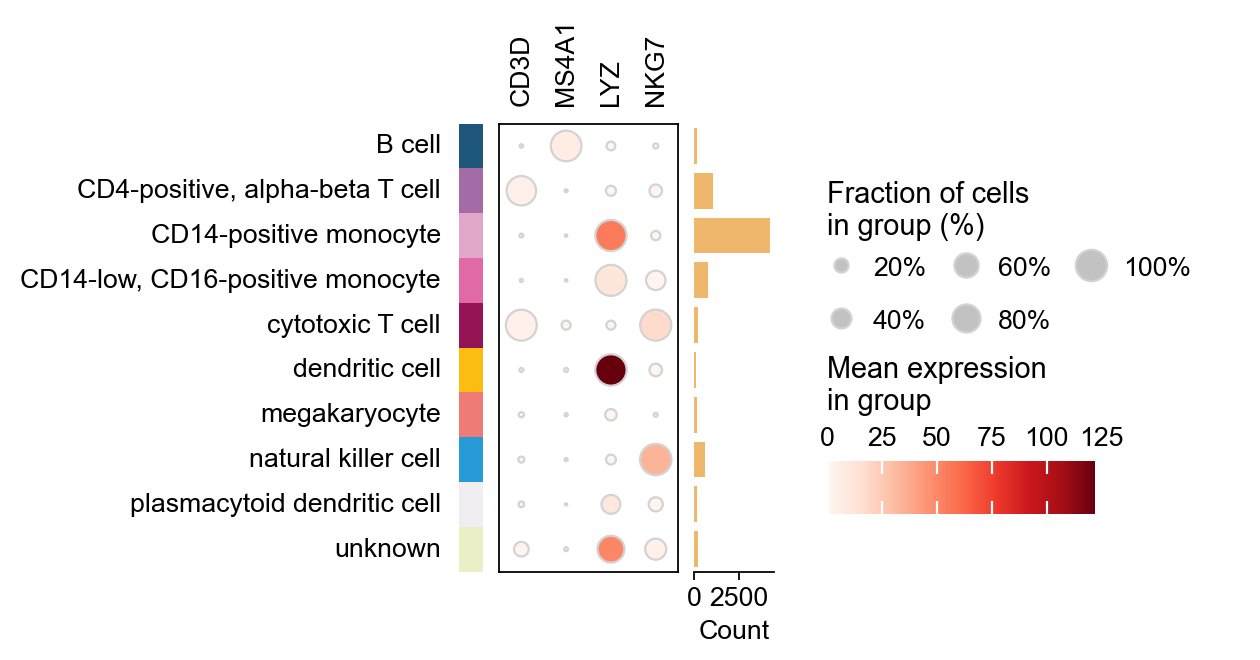

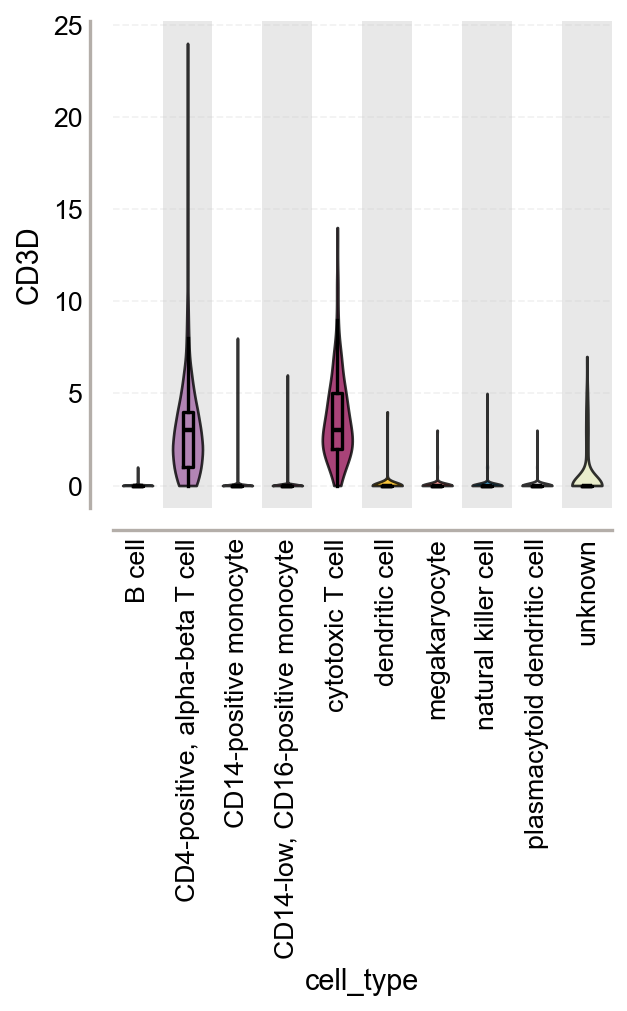

In [24]:
marker_genes = ['CD3D', 'MS4A1', 'LYZ', 'NKG7']

ov.pl.dotplot(
    adata,
    marker_genes,
    groupby='cell_type',
    cmap='Reds',
    figsize=(4, 4),
    show=False,
)
save_figure_pair('figures/plotting/dotplot_markers')
plt.show()

fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.violin(
    adata,
    keys=['CD3D'],
    groupby='cell_type',
    rotation=90,
    stripplot=False,
    show=False,
    ax=ax,
    add_box=True
)
save_figure_pair('figures/plotting/violin_module_score')
plt.show()

## 5. Heatmaps should emphasize structure, not complexity

Heatmaps are powerful because they reveal coordinated patterns across groups. They are also easy to overcomplicate.

Purpose of this step:

- summarize structured differences across cell states, niches, or pathways
- make trends visible at a glance
- keep group-level interpretation readable

Recommended practice:

- cluster only when clustering adds information
- use diverging colormaps for centered values and sequential colormaps for abundance
- keep labels readable before increasing matrix size

In [ ]:
# Example matrix: rows are categories, columns are features/pathways.
# Replace with your own summary matrix.
# matrix = ...

# sns.clustermap(
#     matrix,
#     cmap='RdBu_r',
#     figsize=(8, 8),
#     center=0,
# )
# plt.savefig('figures/plotting/heatmap_signed.png', dpi=300, bbox_inches='tight')
# plt.savefig('figures/plotting/heatmap_signed.svg', dpi=300, bbox_inches='tight')

## 6. Spatial plots should preserve tissue context while remaining interpretable

When plotting spatial transcriptomics or CosMx-style segmentation results, you should treat the image background as **context**, not as the main message.

Why this step matters:

- too much segmentation detail hides biology
- too much biological overlay hides tissue structure
- readers should be able to see both location and pattern without visual overload

Practical rules:

- keep panel shape close to square when possible
- use compact layouts such as `(4, 4)` for a single field of view
- keep contour lines and overlays visually subordinate
- reuse the same category colors used in embeddings and summary plots

In [ ]:
# Example for segmented spatial plotting.
# Adjust keys to your own AnnData object.

sq.pl.spatial_segment(
    adata,
    color='cell_type',
    library_key='fov',
    library_id='1',
    seg_cell_id='cell_ID',
    palette=color_dict,
    img=False,
    figsize=(4, 4),
    dpi=300,
    legend_loc=None,
    frameon='small',
    show=False,
)
save_figure_pair('figures/plotting/spatial_segment_celltype')
plt.show()

## 7. Export for both analysis and publication

Export is not a cosmetic afterthought. It determines whether your figure survives manuscript preparation.

Why save both formats:

- `png` is convenient for quick inspection, slides, and raster-based submissions
- `svg` is better for vector editing, journal layout, and text sharpness

Why `dpi=300` matters:

- below this, labels and small symbols often degrade in print or PDF assembly

Why `bbox_inches='tight'` matters:

- unnecessary margins complicate multi-panel composition

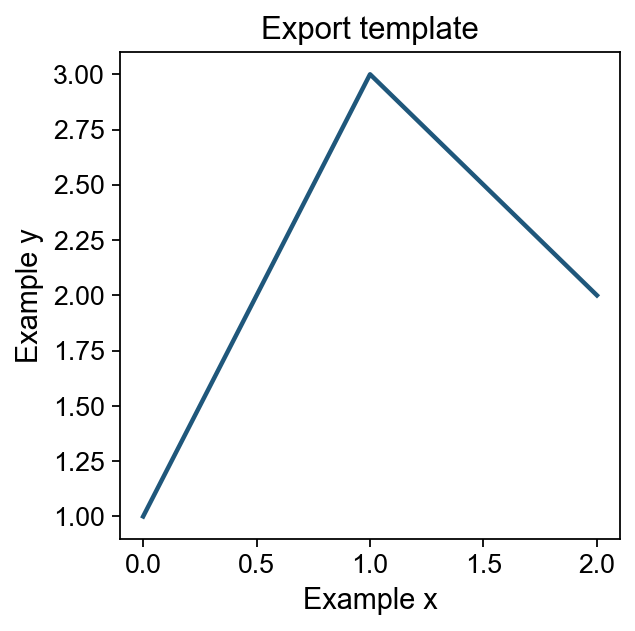

In [25]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([0, 1, 2], [1, 3, 2], lw=2)
ax.set_xlabel('Example x')
ax.set_ylabel('Example y')
ax.set_title('Export template')
save_figure_pair('figures/plotting/export_template')
plt.show()

## 8. A practical checklist before you finalize a figure

Before a figure enters a manuscript, verify the following:

1. **Biological meaning is clear**: the plot answers one question well.
2. **Category colors are stable**: the same cell type is not recolored in another panel.
3. **Colormap logic is correct**: sequential for abundance, diverging for signed contrasts.
4. **Text is readable**: labels are not oversized, but they also do not disappear after export.
5. **Panel geometry is consistent**: similar figures use similar figure sizes.
6. **Legends are under control**: present when needed, suppressed when redundant.
7. **Export is complete**: both `png` and `svg` are saved with `dpi=300`.
8. **The figure can stand alone**: title, axis labels, and color interpretation are understandable without code.

If a figure fails any of these checks, improve the figure before generating more figures.

## Summary

A good scientific figure in `omicverse` is not defined by complexity. It is defined by **consistency**, **semantic color usage**, **appropriate plot choice**, and **clean export**.

A useful working order is:

1. define global style
2. fix categorical palettes
3. choose the correct continuous colormap
4. make the overview plot
5. make the evidence plot
6. export in paired formats

Once you standardize these steps, your plotting workflow becomes faster, more reproducible, and much easier to maintain across a full project.